In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

## Load the MNIST dataset
use fetch_openml to load the mnist_784 dataset.

In [2]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist.data
y = mnist.target.astype(int)

print("Dataset shape:", X.shape)
print("Labels shape:", y.shape)

Dataset shape: (70000, 784)
Labels shape: (70000,)


## Normalize the data
Neural networks work better when the input values are scaled.
Since MNIST pixel values range from 0 to 255, we normalize them to 0 to 1.

In [3]:
Scaler = MinMaxScaler()
X_scaled = Scaler.fit_transform(X)

## Split into training and test sets

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)


print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (56000, 784)
Test set: (14000, 784)


## Sample Data 

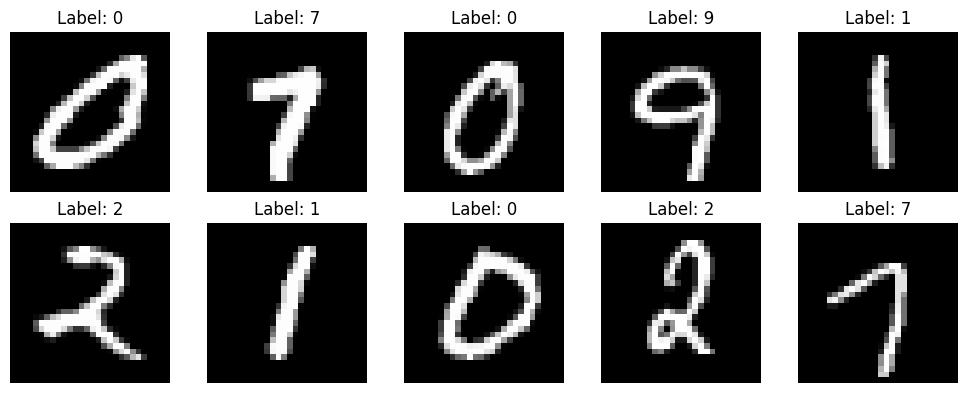

In [5]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## Build the autoencoder

Input layer: 784 neurons
Encoder: compresses into latent representation
Decoder: reconstructs back to 784 neurons

In [6]:
input_dim = 784
latent_dim = 32

# Input
input_img = Input(shape=(input_dim,))

# Encoder
encoded = Dense(128, activation='relu')(input_img)
encoded = Dense(64, activation='relu')(encoded)
latent = Dense(latent_dim, activation='relu', name='latent_vector')(encoded)

# Decoder
decoded = Dense(64, activation='relu')(latent)
decoded = Dense(128, activation='relu')(decoded)
output_img = Dense(input_dim, activation='sigmoid')(decoded)

# Autoencoder model
autoencoder = Model(inputs=input_img, outputs=output_img)

# Encoder model only
encoder = Model(inputs=input_img, outputs=latent)

## Loss function & optimizer 
**Loss Function:** binary_crossentropy
This is suitable because:
- Pixel values are scaled between 0 and 1
- The output layer uses sigmoid, which also produces values between 0 and 1
- It measures how close the reconstructed image is to the original image.

**Optimizer:** Adam
- Adam is widely used because it:
converges faster than standard gradient descent
- Adapts the learning rate automatically
- Works well for image reconstruction tasks

In [7]:
autoencoder.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy'
)

## Train the autoencoder

The input and target are the same:
**input** = original image
**output** = reconstructed version of the same image
That is why we use:
X_train, X_train

In [8]:
history = autoencoder.fit(
    X_train, X_train,
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(X_test, X_test),
    verbose=1
)

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2562 - val_loss: 0.1737
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1545 - val_loss: 0.1385
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1319 - val_loss: 0.1252
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1222 - val_loss: 0.1191
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1171 - val_loss: 0.1150
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1131 - val_loss: 0.1109
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1093 - val_loss: 0.1078
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1066 - val_loss: 0.1059
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1045 - val_loss: 0.1038
Epoch 10/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1026 - val_loss: 0.1019
Epoch 11/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1009 - val_loss: 0.1006
Epoch 12/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

## Plot training & vaildation loss

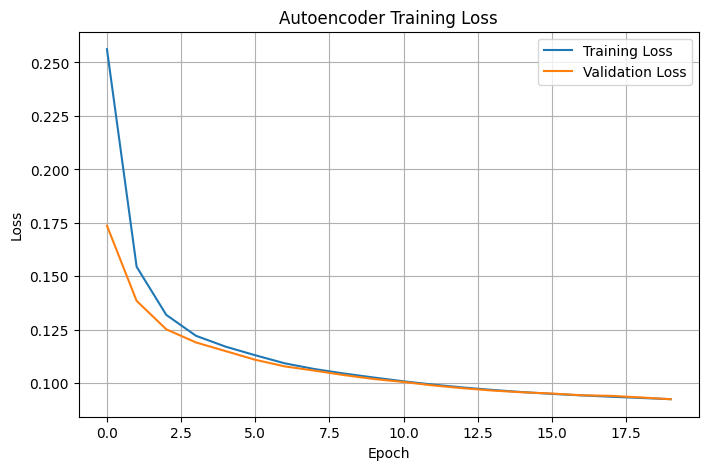

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Autoencoder Training Loss')
plt.legend()
plt.grid(True)
plt.show()

## Reconstruct test images

In [10]:
reconstructed_imgs = autoencoder.predict(X_test)

438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 441us/step


## Compare reconstruced image with original image
The reconstructed images may look slightly blurry, but they should still preserve the digit shape.
This shows that the autoencoder has learned meaningful features.

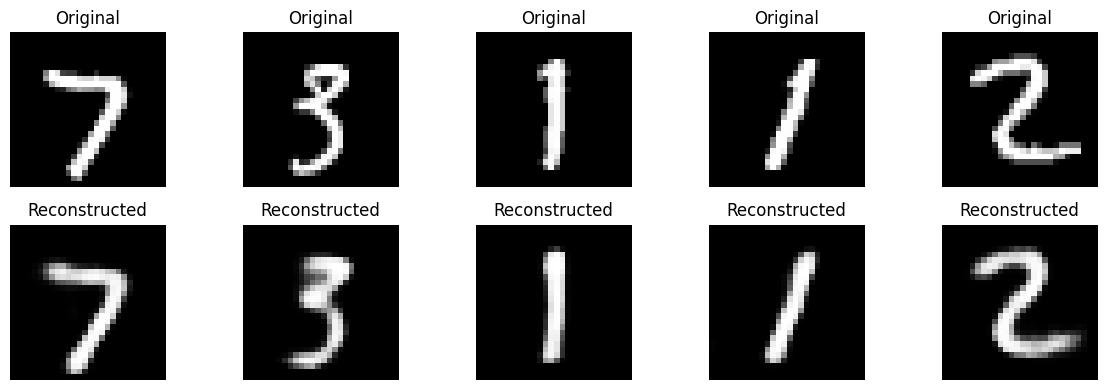

In [11]:
n = 5
plt.figure(figsize=(12, 4))

for i in range(n):
    # Original
    plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.tight_layout()
plt.show()

## Encode the data into latent space

Each 784-dimensional image will be compressed into a 32-dimensional latent vector.
This latent representation stores the most important information needed for reconstruction.

In [12]:
X_train_encoded = encoder.predict(X_train)
X_test_encoded = encoder.predict(X_test)

print("Encoded train shape:", X_train_encoded.shape)
print("Encoded test shape:", X_test_encoded.shape)

1750/1750 ━━━━━━━━━━━━━━━━━━━━ 0s 230us/step
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 266us/step
Encoded train shape: (56000, 32)
Encoded test shape: (14000, 32)


## Reduce latent features to 2D
To visualize the learned representations, reduce them from 32D to 2D using PCA.

In [13]:
pca = PCA(n_components=2)
X_test_2d = pca.fit_transform(X_test_encoded)

## Visualize encoded data in 2D

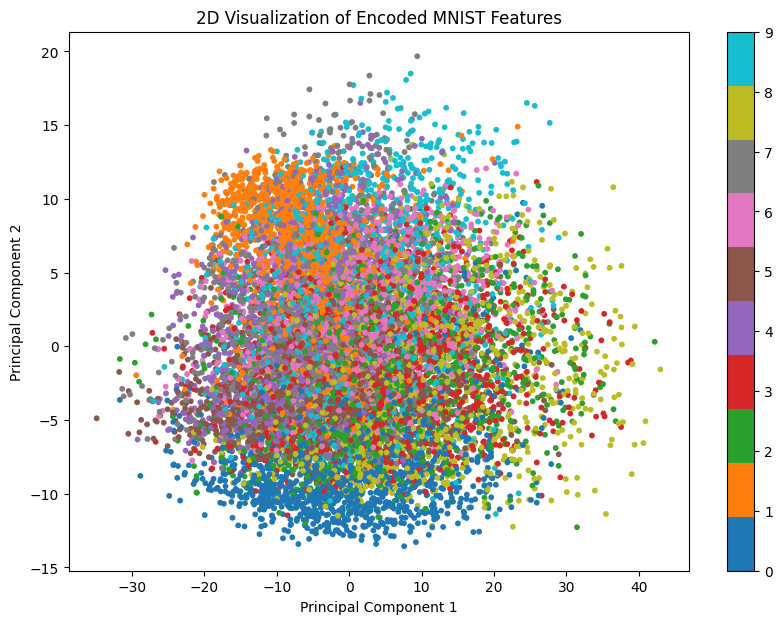

In [14]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_test_2d[:, 0], X_test_2d[:, 1],
    c=y_test, cmap='tab10', s=10
)
plt.colorbar(scatter)
plt.title("2D Visualization of Encoded MNIST Features")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

**Insight** : Digits with similar shapes tend to appear close to each other in latent space.
For example:
1s may cluster together
0s may form another cluster
some digits like 4 and 9 may overlap slightly
This shows that the encoder learned useful compressed features.

## Image retrieval using cosine similarity

Cosine similarity measures the angle between two vectors.
It is useful because:
it compares the direction of feature vectors
it works well in latent spaces
similar images tend to have similar encoded representations
A cosine similarity closer to 1 means the images are more similar.


In [15]:
query_index = 0
query_image = X_test[query_index]
query_label = y_test[query_index]

In [16]:
query_vector = encoder.predict(query_image.reshape(1, -1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [17]:
similarities = cosine_similarity(query_vector, X_train_encoded)[0]
top_k_indices = np.argsort(similarities)[-5:][::-1]

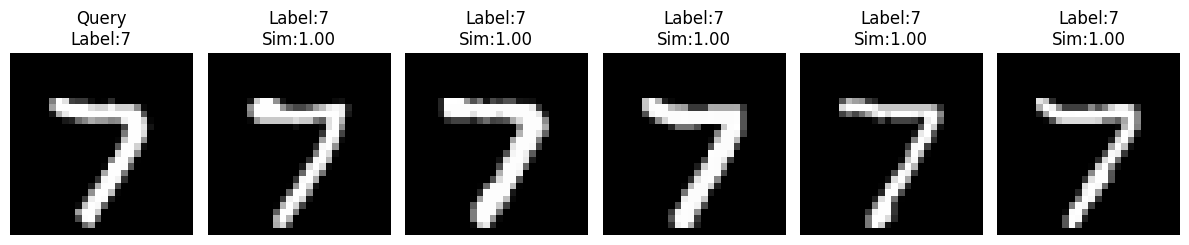

In [18]:
plt.figure(figsize=(12, 3))

# Query image
plt.subplot(1, 6, 1)
plt.imshow(query_image.reshape(28, 28), cmap='gray')
plt.title(f"Query\nLabel:{query_label}")
plt.axis('off')

# Top-5 similar images
for i, idx in enumerate(top_k_indices):
    plt.subplot(1, 6, i + 2)
    plt.imshow(X_train[idx].reshape(28, 28), cmap='gray')
    plt.title(f"Label:{y_train[idx]}\nSim:{similarities[idx]:.2f}")
    plt.axis('off')

plt.tight_layout()
plt.show()